# Analysis and Modeling of Pendulum Timing

The purpose of this analysis is to model pendulum metronome timing with a function simple enough that it can be implemented into any synthesizer, DAW, drum machine, or other device with **minimal performance implications**. The final model should maintain a steady tempo, i.e. if the clock starts at 120bpm, it should still be about 120bpm, regardless of how long the clock has been running.  This will be the primary departure from the physical model of a pendulum metronome.

## Run the cell below to load the data

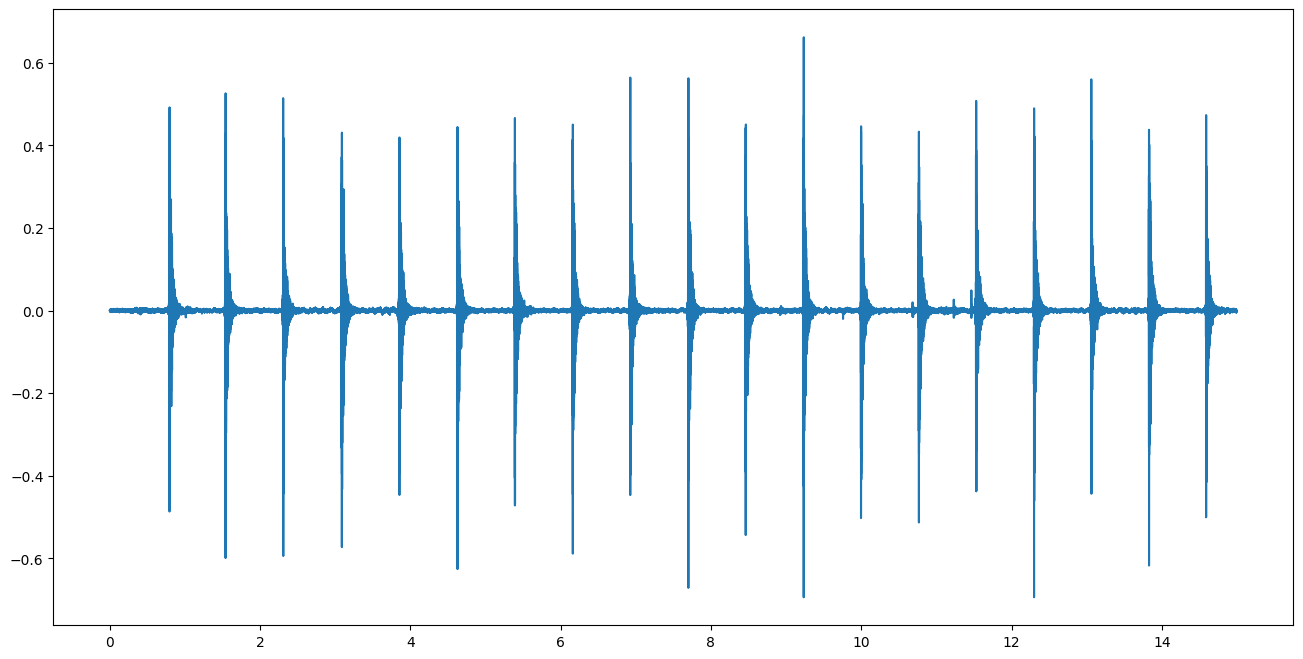

In [2]:
from pathlib import Path
import numpy as np
from numpy.polynomial import Polynomial
from scipy.io import wavfile
from scipy import signal
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm

def init(pathname, plot=False):
    wav_path = Path(pathname)

    fs, sig = wavfile.read(wav_path)   # fs = sample rate (Hz)

    if sig.shape[1] == 2:
        sig = sig[:,0]


    if (plot):
        t = np.arange(len(sig)) / fs
        sec = 15
        n = int(sec * fs)
        plt.figure(figsize=(16,8))
        plt.plot(t[:n], sig[:n])
        plt.show()
    return (sig, fs, len(sig))

sig, sampleRate, original_size = init("metronome test_unwarped2.wav", True)


## De-Noise with Teager-Kaiser Energy Operator

Next I will de-noise the signal by treating it like EMG onset detection.

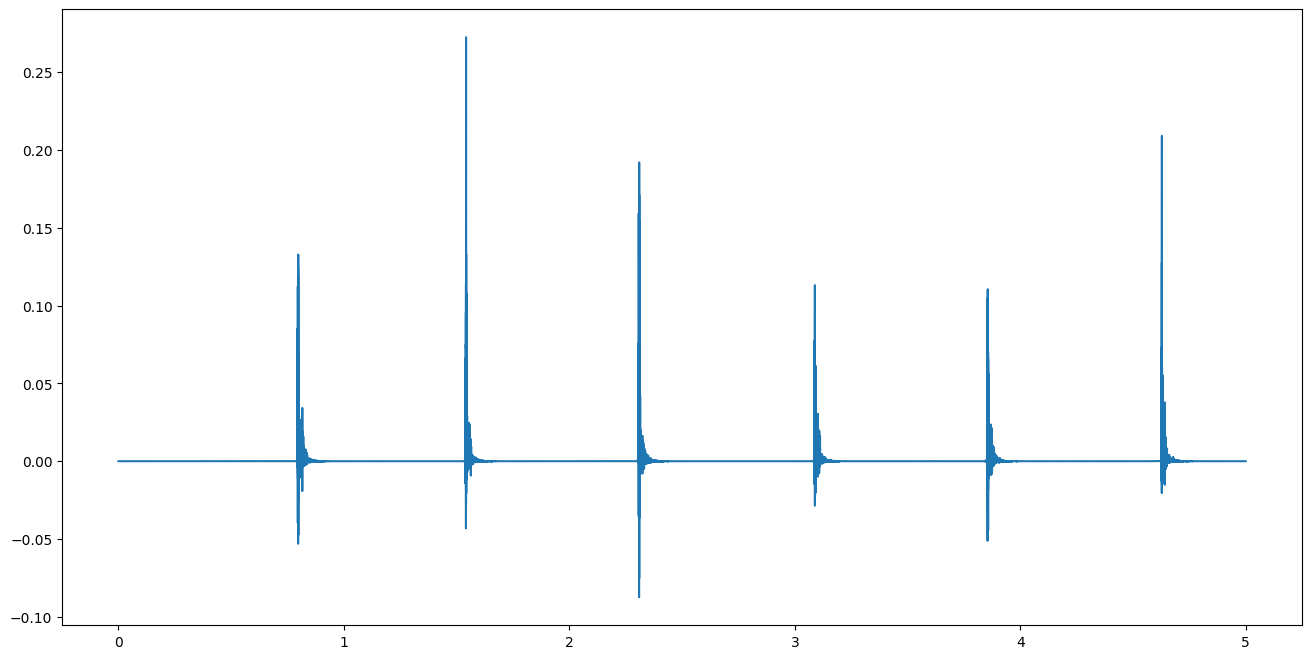

In [3]:
def tkeo_noise_removal(sig: np.ndarray, sampleRate: int=None, plot=False):
    out = sig[1:-1] ** 2 - (sig[:-2] * sig[2:])
    out = np.r_[0,out,0]

    if (plot):
        t = np.arange(len(sig)) / sampleRate
        sec = 5
        n = int(sec * sampleRate)
        plt.figure(figsize=(16,8))
        plt.plot(t[:n], out[:n])
        plt.show()
    return out

sig = tkeo_noise_removal(sig, sampleRate, True)

## Convert Audio Clicks to Triggers

Next I will convert the de-noised clicks into unit impulses based on the timing of peaks.  This is more similar to the way people actually perceive the timing of the beats and doesn't rely on a threshold.

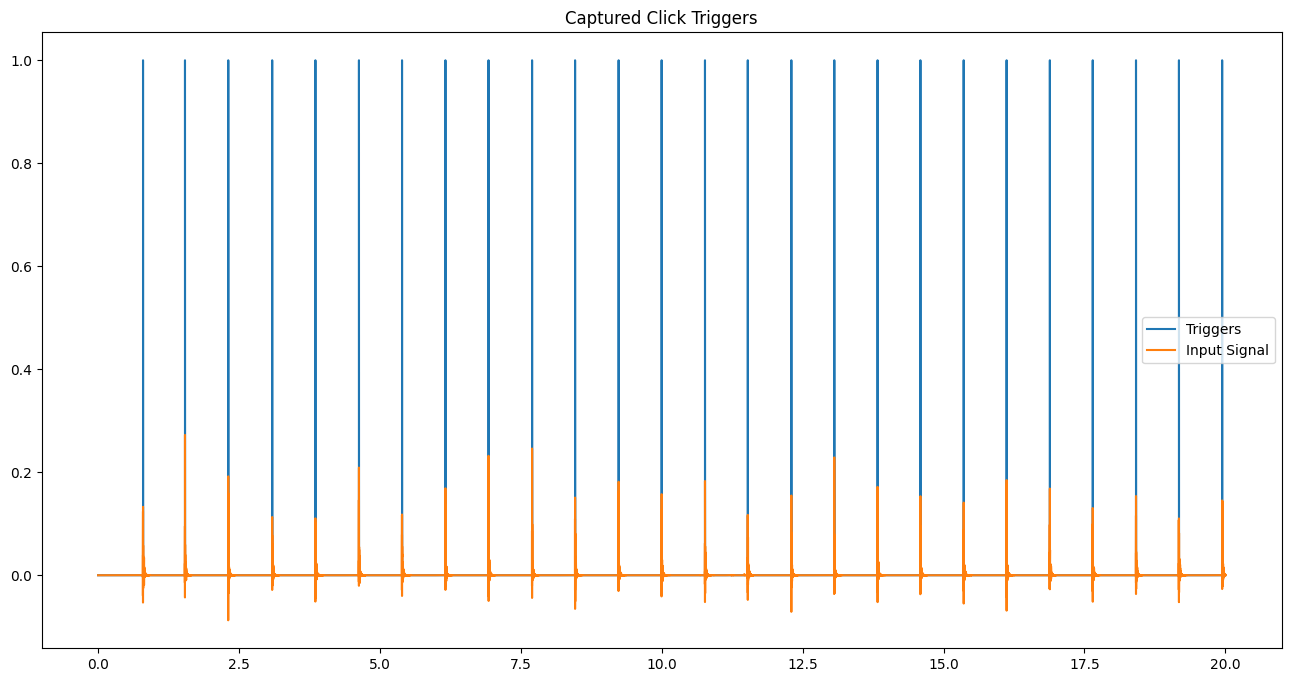

In [4]:
def trig_convert(sig: np.ndarray, sampleRate: int, noise_threshold: float=0.05, 
    plot: bool=False):
    # convert audio to trigs
    noise_threshold = 0.05
    clicks = np.abs(sig) > noise_threshold
    pre_clicks = np.roll(clicks,1) == False
    clicks = np.logical_and(clicks,pre_clicks)
    i_clicks = np.flatnonzero(clicks)

    # rate-limit trigs
    min_sep_s = 0.05
    min_sep = int(min_sep_s * sampleRate)

    i_keep = np.r_[True, np.diff(i_clicks) >= min_sep]
    i_trigs = i_clicks[i_keep]

    trigs = np.zeros(len(sig), dtype=int)
    trigs[i_trigs] = 1

    # separate data into 1 chunk per trig
    chunks = []
    for trig_num, trig_loc in enumerate(i_trigs):
        if trig_num + 1 < len(i_trigs):
            end = i_trigs[trig_num+1] 
        else: 
            end = len(sig)
        chunks.append({'data': sig[trig_loc:end], 'start': trig_loc})

    i_peaks = []
    for chunk in chunks:
        i_peaks.append(np.argmax(chunk['data'])+chunk['start'])

    peaks = np.zeros(len(sig), dtype=int)
    peaks[i_peaks] = 1
    if (plot):
        t = np.arange(len(sig)) / sampleRate
        sec = 20
        n = int(sec * sampleRate)
        plt.figure(figsize=(16,8))
        plt.title("Captured Click Triggers")
        plt.plot(t[:n], peaks[:n], label="Triggers")
        plt.plot(t[:n], sig[:n], label="Input Signal")
        plt.legend()
        plt.show()

    return peaks

trigs = trig_convert(sig, sampleRate, 0.05, True)

## Calculate beat lengths for pattern analysis

The first few beats show a different pattern than the sustained metronome timing, so I will discard them for this analysis.
Using beat lengths rather than the times of the beats allows us to more easily use DSP techniques to analyze the signal.

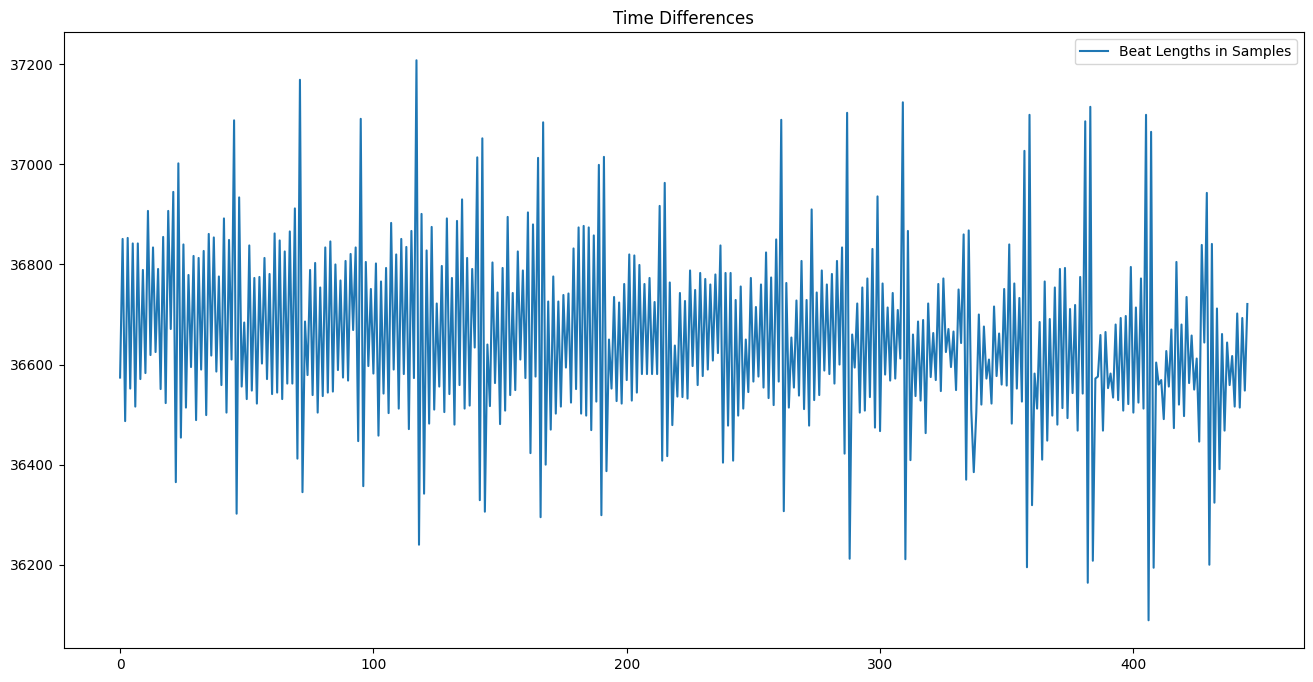

In [5]:
beat_lengths = np.diff(np.nonzero(trigs)[0])
# the first few beats show a different pattern than the rest, so I will discard them
# in favor of the sustained pattern

beat_lengths = beat_lengths[15:-15]
beat = np.arange(len(beat_lengths))
plt.figure(figsize=(16,8))
plt.title("Time Differences")
plt.plot(beat, beat_lengths, label="Beat Lengths in Samples")
plt.legend()
plt.show()

## Model tempo drag

The plot of beat lengths has a gentle downward trend to it.  While this is not an effect I would want to use in a digital recreation of pendulum timing, it is important to account for it in my analysis, and remove it from the reference signal.

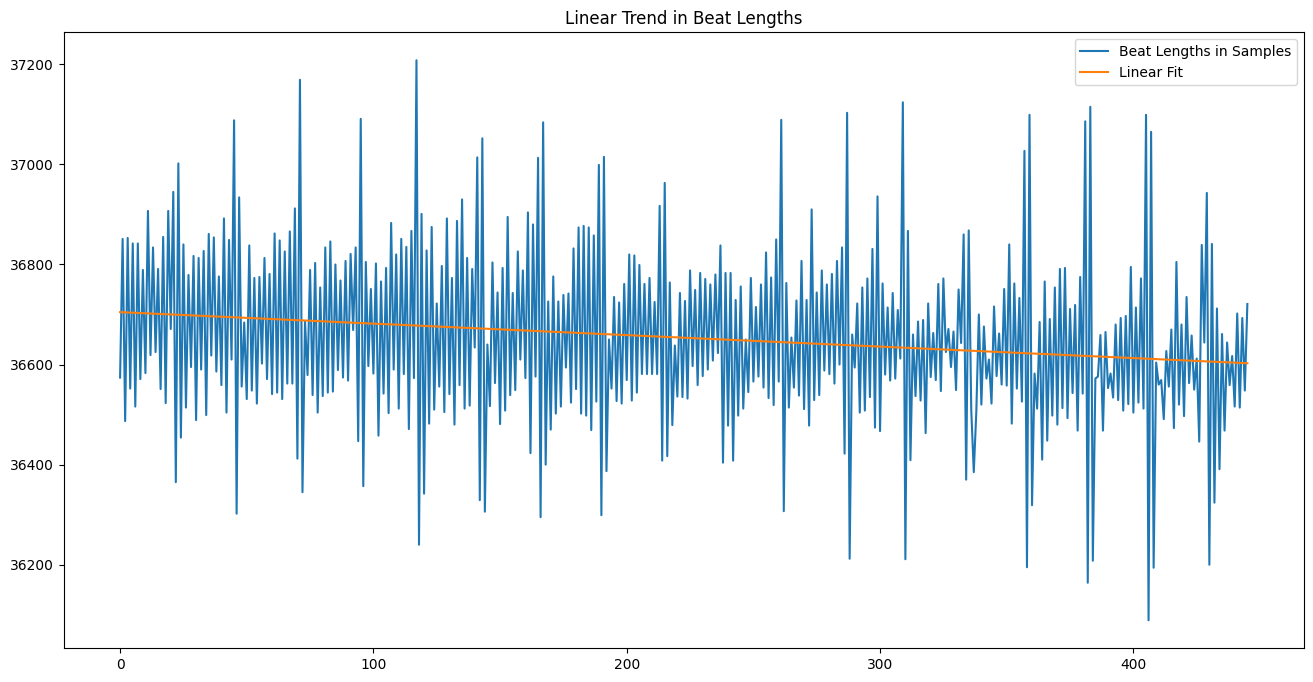

In [6]:
des = np.array([beat, np.ones(len(beat_lengths))]).T
m, c = np.linalg.lstsq(des, beat_lengths)[0]
linear_fit = beat * m + c

plt.figure(figsize=(16,8))
plt.title("Linear Trend in Beat Lengths")
plt.plot(beat, beat_lengths, label="Beat Lengths in Samples")
plt.plot(beat, linear_fit, label="Linear Fit")
plt.legend()
plt.show()

## Remove tempo drag for further analysis

Tempo drag will skew our results, so I will remove it from the beat lengths and perform the remaining analysis on the residual.  I will also center and normalize the signal for easy processing.

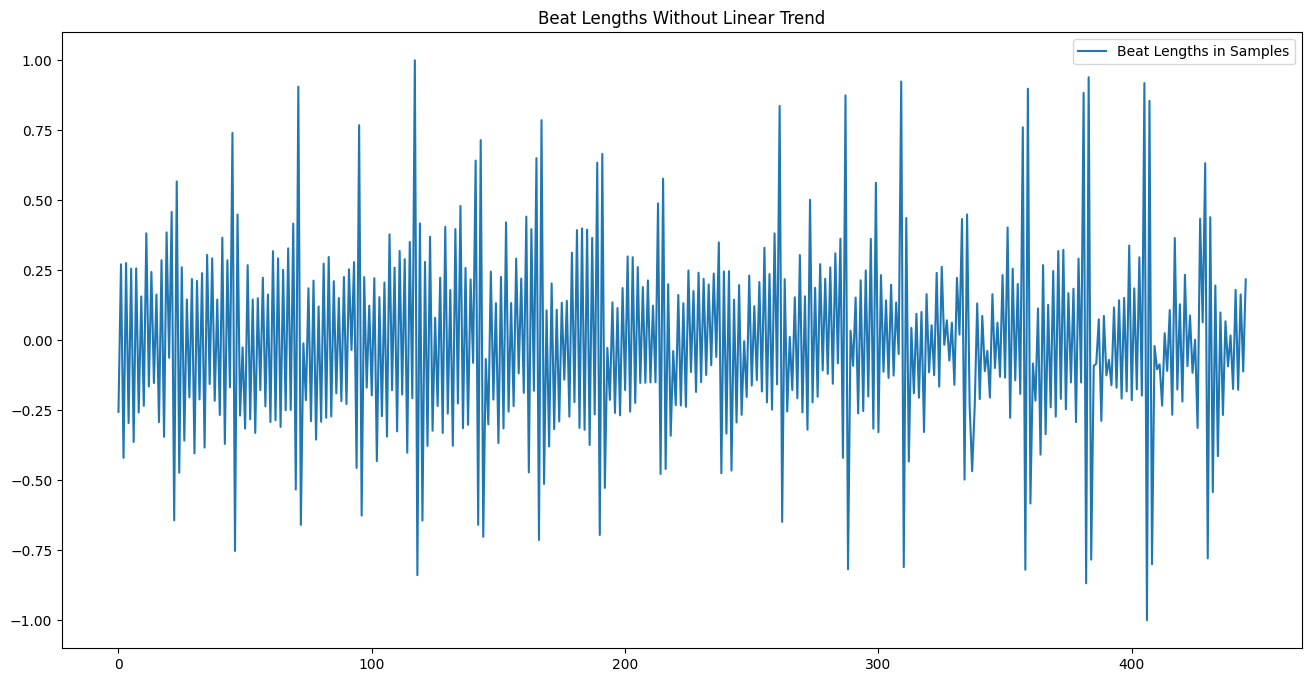

In [7]:
def normalize(sig):
    center = np.mean(sig)
    scale = (np.max(sig) - np.min(sig)) / 2
    normalized = ((sig - np.min(sig)) / (scale*2)) * 2 - 1
    return (normalized, center, scale)

stable_beat_lengths = beat_lengths - beat * m
centered_stable_beat_lengths = stable_beat_lengths + c
bl, center, scale = normalize(centered_stable_beat_lengths)

plt.figure(figsize=(16,8))
plt.title("Beat Lengths Without Linear Trend")
plt.plot(beat, bl, label="Beat Lengths in Samples")
plt.legend()
plt.show()

## Model constant swing

There is a clear alternating pattern representing the "swing" of the metronome.  I will scale the swing using the median due to extreme swing amplitude values (which will be modeled later).

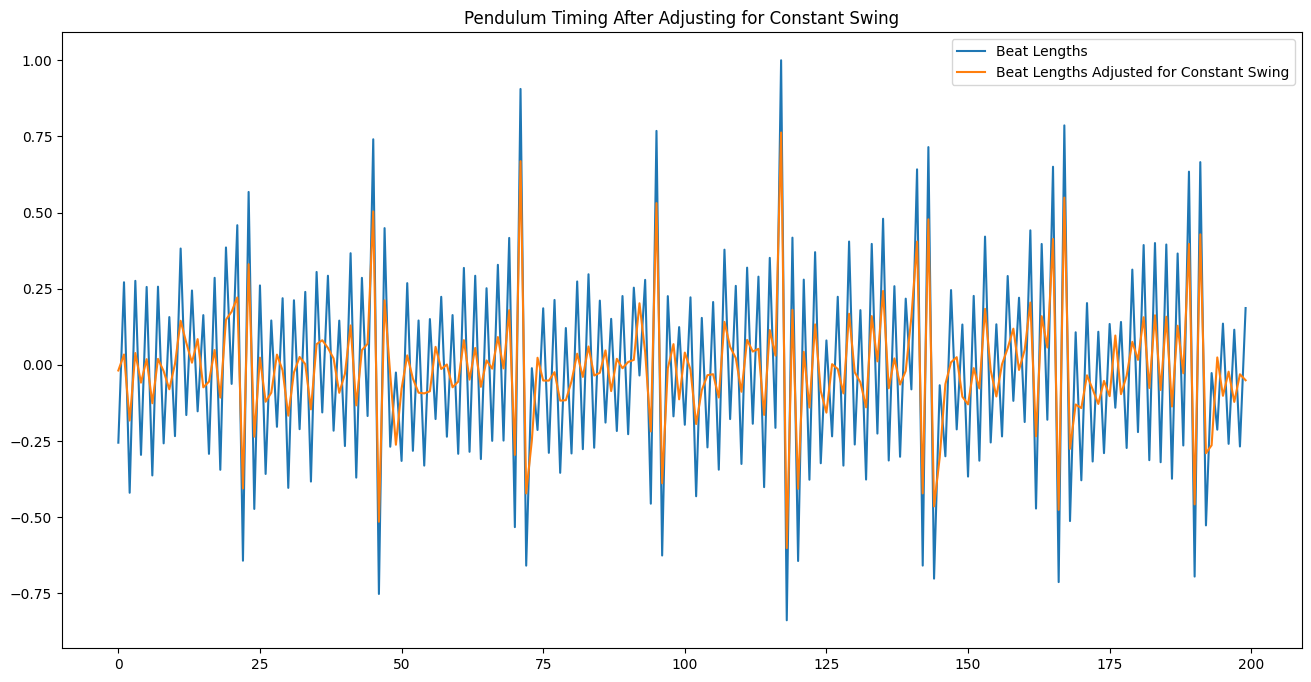

In [8]:
def model_constant_swing(sig: np.ndarray, threshold: float=0.3, plot=False):
    beat = np.arange(0,len(sig))
    swing = np.arange(len(beat)) % 2
    swing = -1 * (-swing * 2 + 1)
    t = np.arange(0,len(sig))
    scale = np.median(np.abs(sig))
    swing = swing * scale
    residual = sig - swing

    #plt.plot(beat, swing)
    if (plot):
        n = 200
        plt.figure(figsize=(16,8))
        plt.plot(beat[:n], sig[:n], label='Beat Lengths')
        plt.plot(beat[:n], residual[:n], label="Beat Lengths Adjusted for Constant Swing")
        #plt.plot(beat[:n], swing[:n], label="Constant Swing")

        plt.title("Pendulum Timing After Adjusting for Constant Swing")
        # plt.savefig("Pendulum Timing After Adjusting for Constant Swing.png", dpi=300)
        plt.legend()
        plt.show()
    return (swing, scale, residual)

swing, swing_scale, swing_res = model_constant_swing(bl, plot=True)

## Model swing amplitude modulation

The amplitude of swing makes clear jumps every 24 beats.  I will model this using a triangular pulse wave.

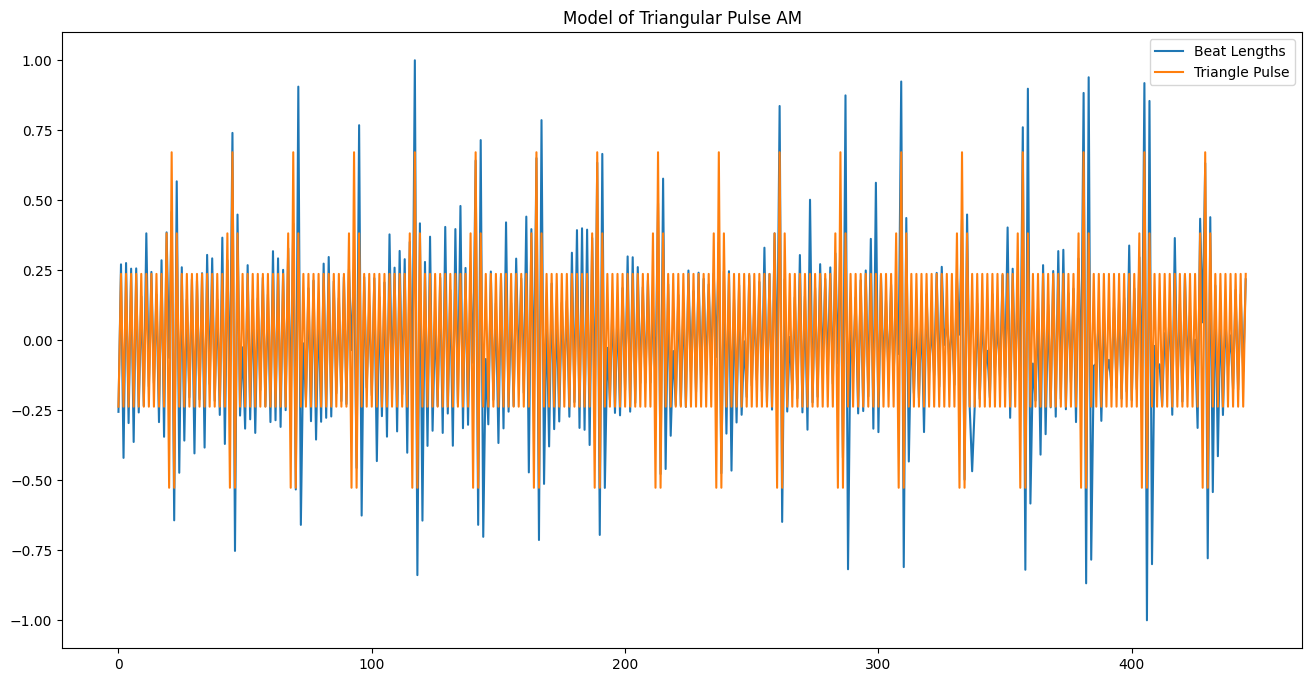

In [9]:
def model_am_tri_pulse(sig, swing, plot=False):
    beat = np.arange(0, len(sig))

    tri_pulse = np.array([1/3, 2/3, 1, 2/3, 1/3])
    tri_pulse = np.pad(tri_pulse, (19, 0))
    num_pulses = int(np.ceil(len(sig) / 24))
    tri_pulse = np.tile(tri_pulse, num_pulses)[:len(sig)]

    # center tri pulse
    rss = np.array([0.0] * 24)
    for r in range(0,24):
        test = np.roll(tri_pulse, r)
        rss[r] = np.sum(np.square(test-sig))
    tri_pulse = np.roll(tri_pulse, np.argmin(rss))

    unscaled_tri_pulse = tri_pulse + 1
    # scale triangle using least-squares
    abs_swing = np.abs(swing)
    x = abs_swing * np.abs(tri_pulse)
    r = np.abs(np.abs(sig) - abs_swing)
    tri_scale = (x.T @ r) / (x.T @ x)
    tri_pulse = (tri_pulse * tri_scale) + 1
    residual = sig - swing * tri_pulse

    model = tri_pulse * swing

    if (plot):
        plt.figure(figsize=(16,8))
        plt.plot(beat, sig , label = "Beat Lengths")
        plt.plot(beat, model, label="Triangle Pulse")
        plt.title("Model of Triangular Pulse AM")
        plt.legend()
        plt.show()
    
    return (model, tri_scale, unscaled_tri_pulse)

tri_pulse_swing, tri_scale, tri_pulse = model_am_tri_pulse(bl, swing, True)

## Model low-frequency ramp

There appears to be a small low frequency ramp between the extreme points of the beat lengths.  I determined experimentally that the period is 24, and phase offset is 22.  I also attempted to use a Fourier transform to do this but the result wasn't as accurate.

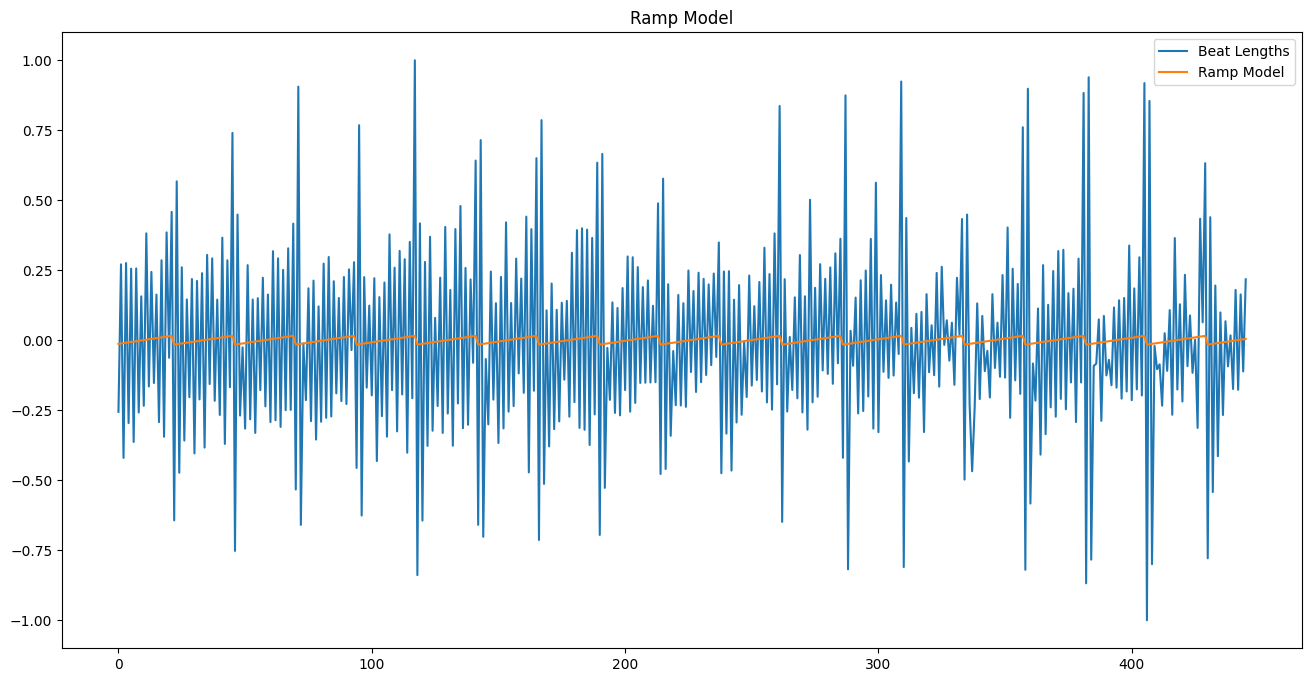

In [10]:
def model_ramp(sig, input_model, cycle_length, start_point, plot=False):
    num_tiles = int(np.ceil(len(sig) / cycle_length))
    beat = np.arange(0, len(sig))
    model = [0] * cycle_length
    for s in range(0, cycle_length):
        model[s] = s / cycle_length
    model = np.roll(model, start_point)
    model = np.tile(model, num_tiles)[:len(sig)]

    # center model
    model = model - np.mean(model)
    
    # scale ramp
    scale = np.dot((sig-input_model).T, model) / np.dot(model.T, model)
    model = model * scale
    if (plot):
        plt.figure(figsize=(16,8))
        plt.plot(beat, sig, label = "Beat Lengths")
        plt.plot(beat, model * scale, label="Ramp Model")
        plt.title("Ramp Model")
        plt.legend()
        plt.show()
    return model

ramp = model_ramp(bl, tri_pulse_swing, 24, 22, True)

## Create Final Clean Model

I will now fit a full model using least-squares, including constant, swing, ramp and swing x tri_pulse factors.

In [11]:
# scale predictors
swing = normalize(swing)[0]
ramp = (ramp - np.min(ramp)) / (np.max(ramp) - np.min(ramp))
# don't normalize tri_pulse
rng = np.random.default_rng(seed=199999)
noise = rng.normal(loc=0, scale=1, size=len(bl)) 

preds = pd.DataFrame({'swing': swing, 'ramp': ramp, 'swing x tri_pulse': swing*tri_pulse})
preds = sm.add_constant(preds)
regression = sm.OLS(bl,preds).fit()
print(regression.summary())

coefs = regression.params
model = np.dot(preds, coefs)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     495.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          5.78e-141
Time:                        09:32:56   Log-Likelihood:                 174.82
No. Observations:                 446   AIC:                            -341.6
Df Residuals:                     442   BIC:                            -325.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1116      0.01

## Add noise

The selected clean model accounts for 76.9% of the sample variance of the signal.  By computing the standard deviation of the residuals, I can determine the maximum amount of noise I might want to add.  Since I know there is some simplification error, I will use 1/3 of the maximum.

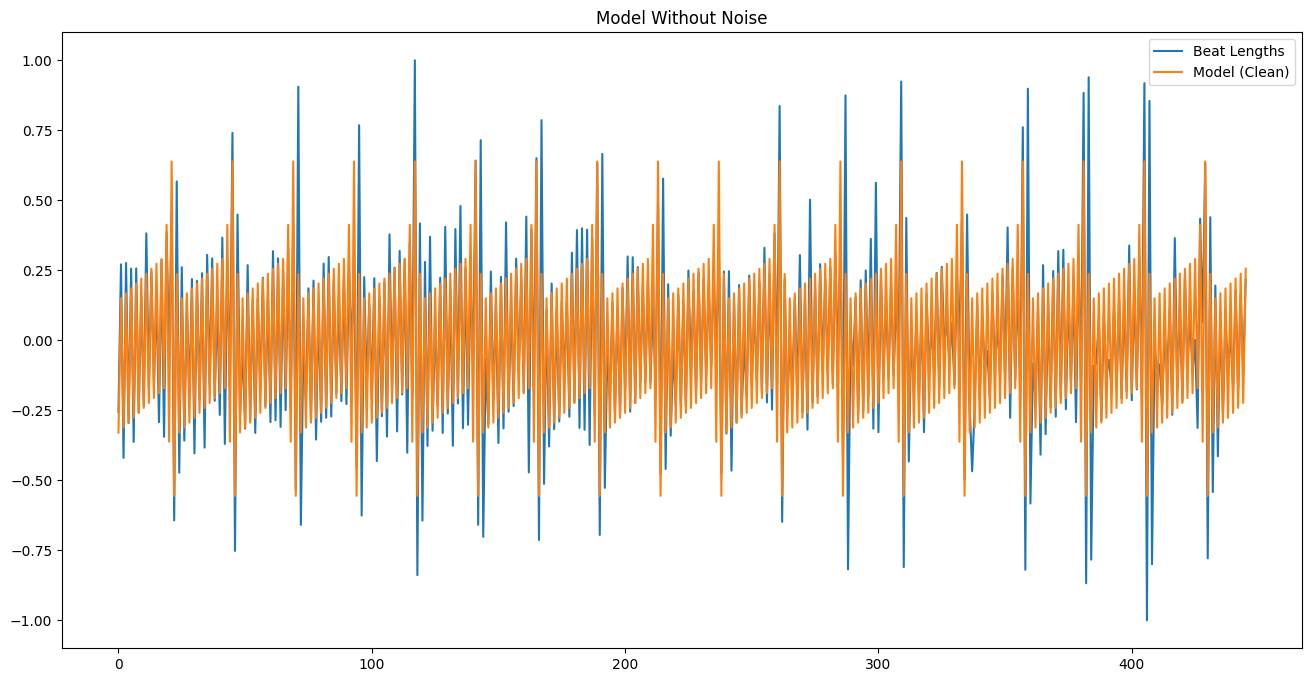

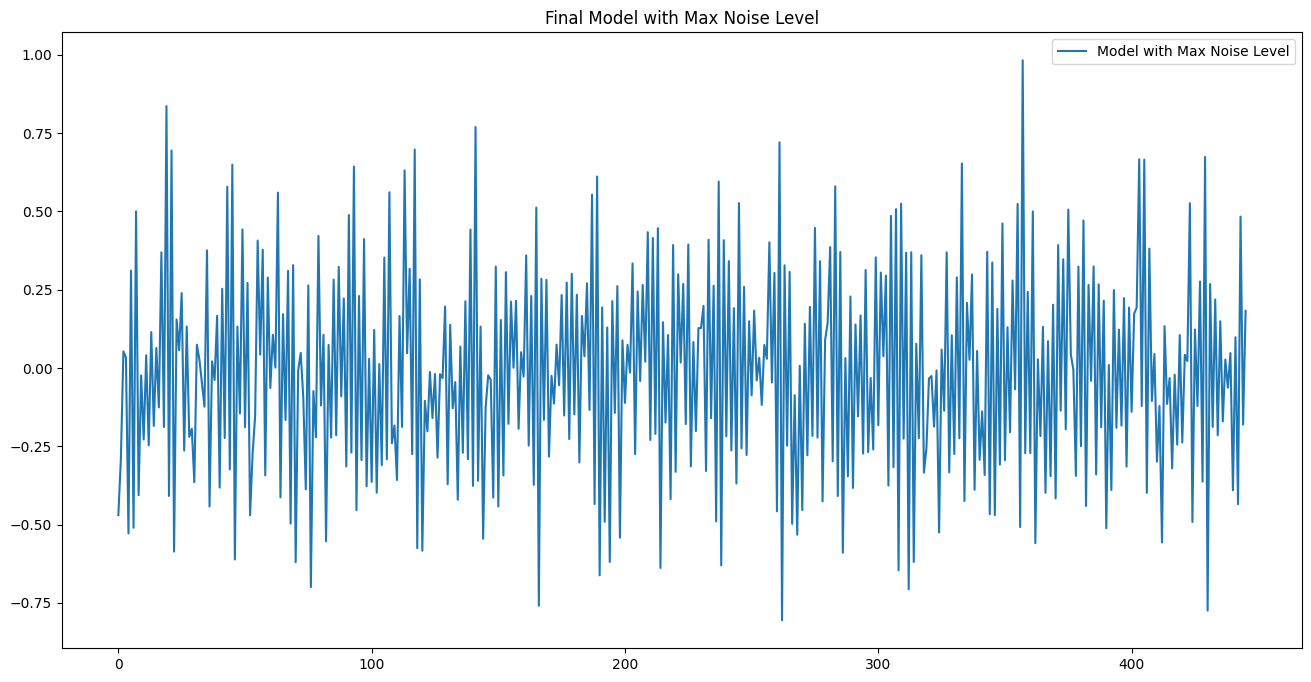

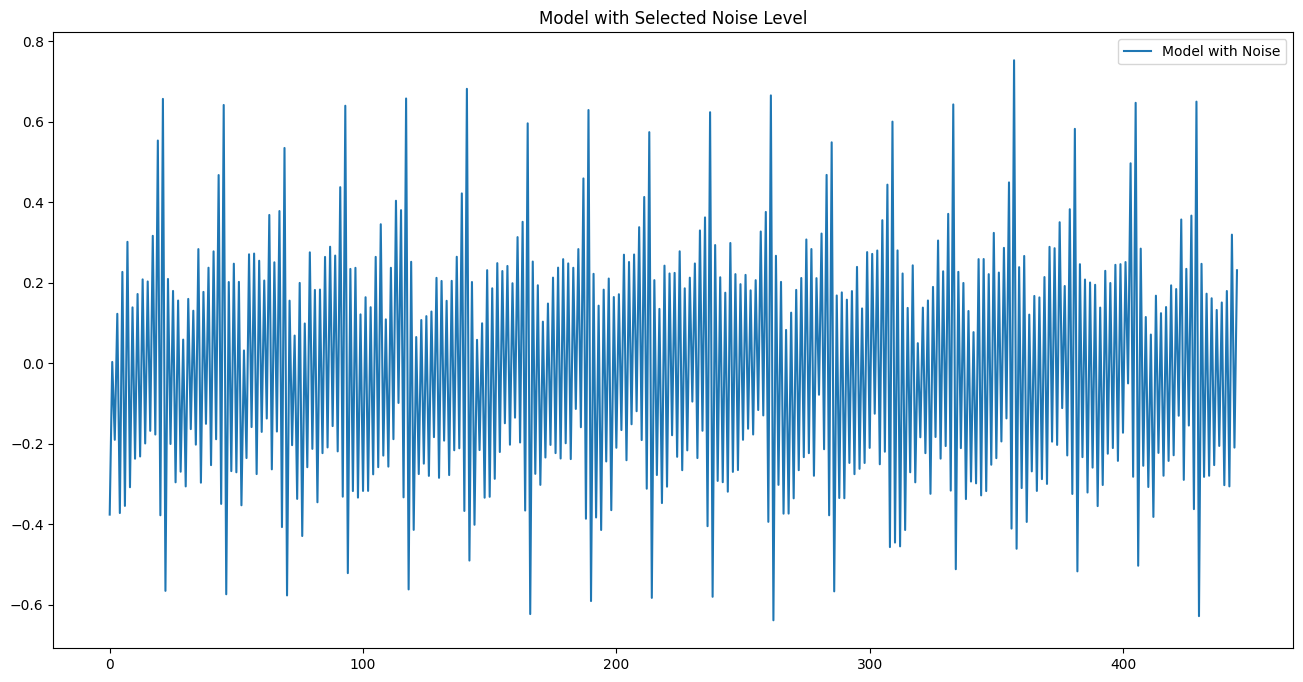

In [12]:
plt.figure(figsize=(16,8))
plt.plot(beat, bl, label="Beat Lengths")
plt.plot(beat, model, label="Model (Clean)")
plt.title("Model Without Noise")
plt.legend()
plt.show()

max_noise_scale = np.std(regression.resid)
rng = np.random.default_rng(seed=199999)
max_noise = rng.normal(loc=0, scale=max_noise_scale, size=len(bl)) 
max_noise_model = model + max_noise

noise_scale = 1/3
selected_noise = max_noise * noise_scale
selected_noise_model = model + selected_noise

plt.figure(figsize=(16,8))
plt.plot(beat, max_noise_model, label="Model with Max Noise Level")
plt.title("Final Model with Max Noise Level")
plt.legend()
plt.show()

plt.figure(figsize=(16,8))
plt.plot(beat, selected_noise_model, label="Model with Noise")
plt.title("Model with Selected Noise Level")
plt.legend()
plt.show()

## Prepare model to be scaled by bpm
The model is currently in the form of a normalized beat length.  To create a sequence-style model, I want something that can be easily scaled by bpm for implementation in a drum machine or synthesizer.  If 1 represents the length of a beat at the desired tempo, the model should output a 1 for a perfectly-timed beat, something like 1.1 for a beat that will be at 110% of the tempo, 0.95 for a beat that will be at 95% of the tempo, etc.

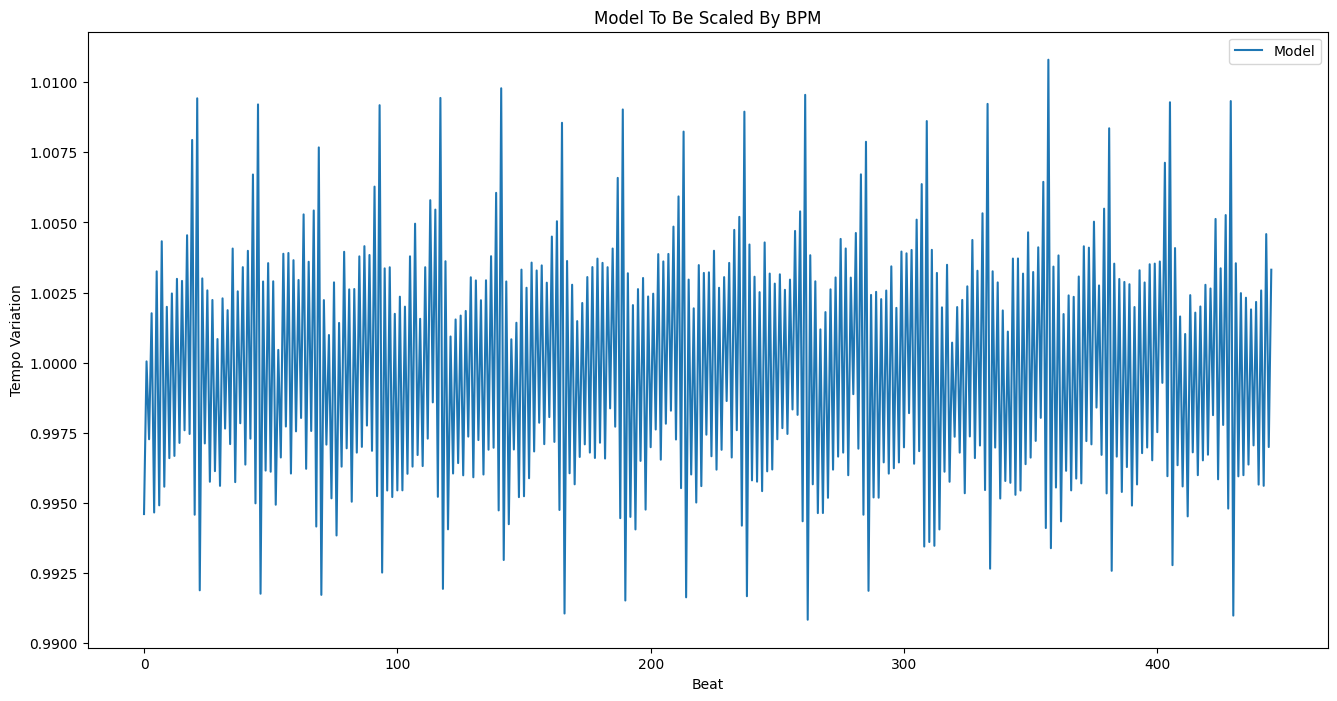

In [13]:
# these values are from the scaling we did earlier
unscaled = (selected_noise_model * scale + c)
beat_length = np.mean(unscaled) 
final_model = (unscaled) / beat_length

model_scale = scale / np.mean(unscaled)

rng = np.random.default_rng(seed=199999)

# to scale the model coefficients, multiply all by model_scale then add 1
# to the constant term
scaled_coefs = coefs * model_scale
scaled_coefs['const'] = scaled_coefs['const'] + 1
scaled_coefs['noise'] = model_scale * noise_scale * max_noise_scale
preds['noise'] = rng.normal(loc=0, scale=1, size=len(bl)) 
final_model = np.dot(preds, scaled_coefs)
#
# so if I multiply this by whatever tempo I want, I'll get the model

plt.figure(figsize=(16,8))
plt.plot(beat, final_model, label="Model")
#plt.plot(beat, stable_beat_lengths, label="original")
#plt.plot(beat, final_model, label = "Final Model")
#plt.plot(beat, new_model, label = "recreated model")
plt.title("Model To Be Scaled By BPM")
plt.ylabel("Tempo Variation")
plt.xlabel("Beat")
plt.legend()
#plt.savefig('Model To Be Scaled By BPM.png', dpi=300)
plt.show()


## Define the resulting sequence

Finally I will define a sequence representing the model. Let $\beta_n$ represent the duration of beat $n$, and $\epsilon_n$ represent a random sequence with a standard normal distribution. Let $c$ represent a centering constant. Then the equation of these results is as follows:

$$
\beta_{n} = bpm\cdot\big[\sigma_n\left(s + t\tau_n\right) + r\rho_n + e\epsilon_n + c\big]
$$
where
$$
\sigma_n = (-1)^{n+1} \qquad\text{(swing)}
$$
$$
\tau_n = 1+ \max\left(0, \frac{|1-k_n|}{3}\right) \qquad\text{(triangle pulse)}
$$
$$
\rho_n = \frac{\phi_n + 1 \mod 24}{23} \qquad\text{(ramp)}
$$
$$
k_n = \phi_n + 4 \mod 24
$$ 
$$
\phi_{n+1} = \phi_n + 1 \mod 24.
$$




Residual: -4.121147867408581e-13


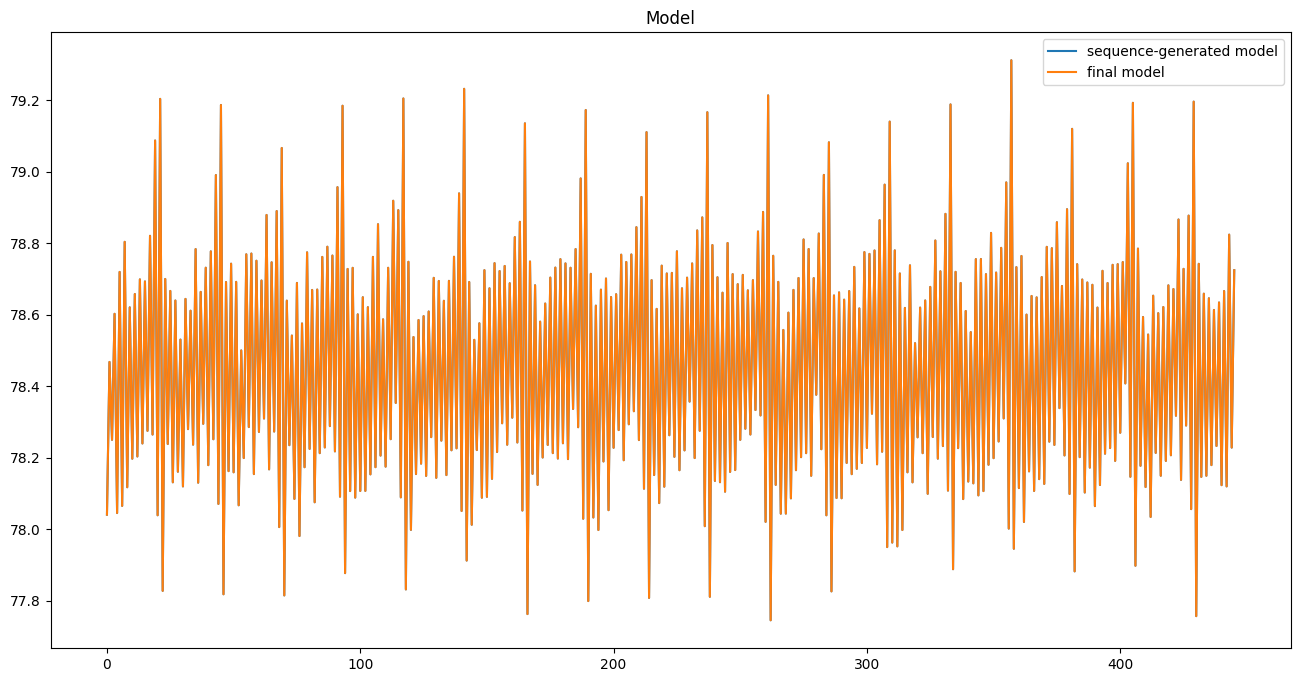

In [14]:
def generate_seq_model(bpm, length, period, seed=199999):
    # coefficients generated above
    # hard-coded for portability
    swing_scale = -0.0011113647547561134
    tp_scale = 0.00448774156806485
    ramp_scale = 0.0028970725823092695
    noise_scale = 0.0007816665998291817
    const_scale = 0.9983995858407179
    model = np.array([0.0] * length)
    rng = np.random.default_rng(seed=seed)
    # c-style loop for clarity
    for i in range(0, length):
        phi = (i + 1) % period
        k = (phi + 4) % period
        s = (-1)**(i+1)
        t = (max(0,1 - abs((k-2))/3) + 1)
        r = ((phi + 1) % period) / (period - 1)
        e = rng.normal(loc=0, scale=1, size=1)[0]
        model[i] =  bpm * (
            s * (swing_scale + t * tp_scale)
            + ramp_scale*r
            + noise_scale*e
            + const_scale
            )
    return model

def test_sequence(original, model, sampleRate, scale_coefs, period):
    const_scale = scale_coefs['const']
    swing_scale = scale_coefs['swing']
    ramp_scale = scale_coefs['ramp']
    tp_scale = scale_coefs['swing x tri_pulse']
    noise_scale = scale_coefs['noise']
    
    bpm = 60 * sampleRate / np.mean(original)
    new_model = generate_seq_model(bpm, len(original), period)
    print(f"Residual: {np.sum(final_model * bpm - new_model)}")

    plt.figure(figsize=(16,8))
    #plt.plot(beat, original * bpm * bpm / (sampleRate* 60), label="original beat lengths")
    plt.plot(beat, new_model, label = "sequence-generated model")
    plt.plot(beat, final_model * bpm, label = "final model")
    plt.title("Model")
    plt.legend()
    plt.show()
    return new_model

seq_model = test_sequence(stable_beat_lengths, selected_noise_model, sampleRate, scaled_coefs, 24)

## Generate .wav file from model 

The sequence-generated model perfectly fits the original model.  But we can look at plots all day without knowing if the model really *feels* like a pendulum metronome.  Let's take a listen.

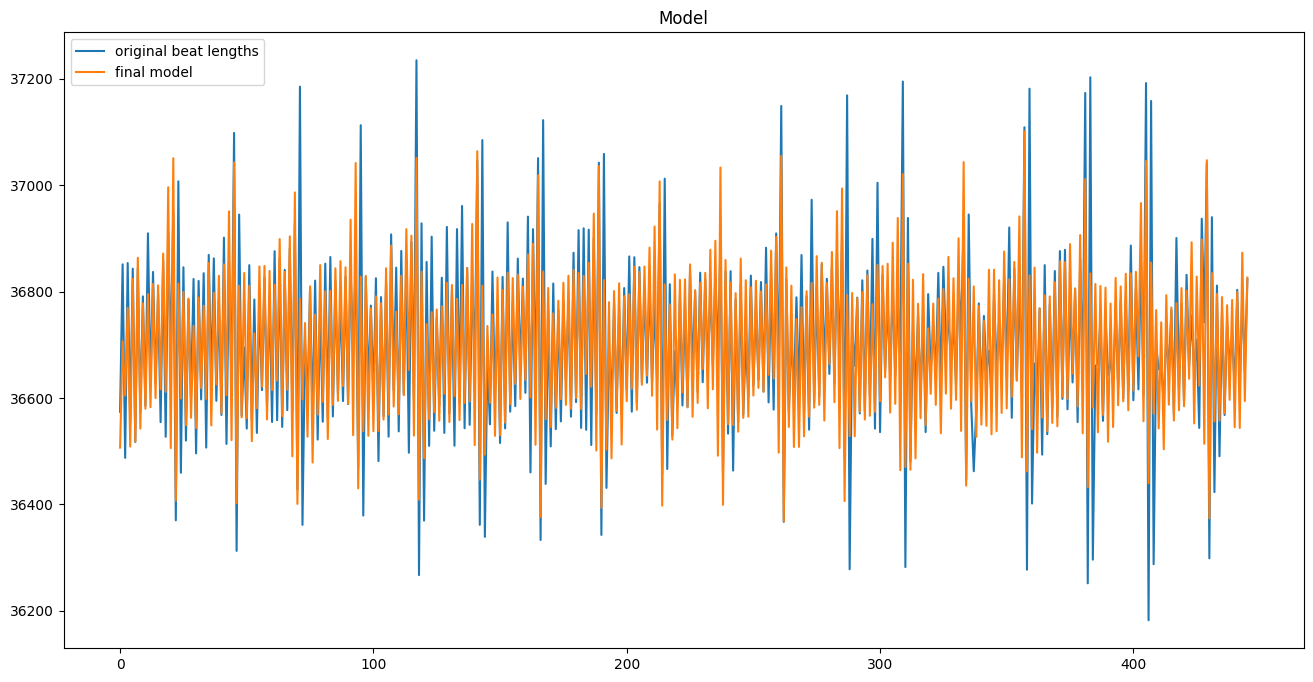

In [15]:
out_filename = "seq_gen_output.wav"
bpm = 60 * sampleRate / np.mean(stable_beat_lengths)
model_beat_lengths = seq_model * sampleRate * 60 / (bpm * bpm)

plt.figure(figsize=(16,8))
plt.plot(beat, stable_beat_lengths, label="original beat lengths")
plt.plot(beat, model_beat_lengths, label = "final model")
plt.title("Model")
plt.legend()
plt.show()

beat_locs = np.cumsum(model_beat_lengths).astype(int)
new_wav = np.zeros(original_size)
new_wav[beat_locs] = 1

new_wav_int16 = np.int16(new_wav * 32767)

wavfile.write(out_filename, sampleRate, new_wav_int16)


# Discussion of results

This model is simple enough to be implemented at very low computing cost.  It neglects to account for the linear drag real pedulum metronomes have, although estimates for coefficients of those parameters are also provided.  It also appears to under-estimate the variance in tempo every 24 beats. The clean model (without noise) accounts for 76.9% of the variance in the original data.
The final amount of noise added was the only factor not derived procedurally; instead a maximum noise amount was derived and the selected noise was chosen to be less.  This is due to the fact that this model does not account for all physical factors, but rather the most statistically significant of those tested.

Other techniques I attempted were Fourier Series Regression (ineffective at low-orders), modeling the amplitude spike with a flat pulse wave,  modeling amplitude with Fourier series (also ineffective at low-orders), and polynomial regression.

Further improvements could be made to this model by increasing the number of recordings used in analysis, including a larger data set of similar tempos and different tempos.  In the current model the effects of the different factors increase linearly with bpm.  This may or may not be true and requires further analysis.

Upon hearing the recording, I determined that the output of the model does "feel" like a pendulum metronome and will function as a suitable replacement.  I also listened to the clean model, which also feels very good.  It's less hypnotic but has more groove. I will be experimenting with them both in my virtual synthesizer, the supersonicACCELERATOR.